# 03 - Evaluation & Interpretation
**Kompetisi:** INFEST XII 2026 - Data Science (Klasifikasi Aksara Tradisional Nusantara)
**Tim:** Fadhil - Percobaan 1

Notebook ini melakukan evaluasi mendalam terhadap model terbaik (`best_model.pt`, Val F1 Macro
0.9939) yang dihasilkan dari `02_modeling.ipynb`. Sudah dikonfirmasi tidak ada data leakage
(overlap hash train-val = 0), sehingga fokus di sini adalah memahami **di mana model masih
salah** dan **kenapa**, bukan sekadar melaporkan angka F1 yang tinggi.

**Perhatian khusus (berdasarkan temuan eksplorasi sebelumnya):**
- Kelas `jawi` mengandung sampel noise/mislabel (ditemukan gambar teks Latin "ng", "DAFTAR")
- Kelas `pegon` punya kualitas scan paling tidak konsisten (noise berat di sebagian sampel)
- `jawi` dan `pegon` sama-sama berbasis aksara Arab, berpotensi mirip secara visual

**Isi notebook:**
1. Setup & Load Model Terbaik
2. Prediksi Penuh pada Validation Set
3. F1-Score per Kelas (Breakdown)
4. Confusion Matrix
5. Analisis Kelas Bermasalah (Jawi & Pegon)
6. Analisis Error: Sampel yang Salah Prediksi
7. Kesimpulan & Rekomendasi


## 1. Setup & Load Model Terbaik

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from sklearn.metrics import f1_score, classification_report, confusion_matrix

SEED = 42
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_DIR = "../dataset"
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "images", "train")
ARTIFACT_DIR = "../artifacts"

val_split_df = pd.read_csv(os.path.join(ARTIFACT_DIR, "val_split.csv"))

with open(os.path.join(ARTIFACT_DIR, "preprocessing_config.json")) as f:
    config = json.load(f)

TARGET_SIZE = tuple(config["target_size"])
classes_sorted = config["classes"]
label_to_idx = config["label_to_idx"]
idx_to_label = {v: k for k, v in label_to_idx.items()}

print("Classes:", classes_sorted)
print("Val set size:", len(val_split_df))


Device: cuda
Classes: ['bali', 'jawa', 'jawi', 'lampung', 'lontara', 'pegon', 'sunda']
Val set size: 671


In [2]:
def resize_with_padding(img, target_size=TARGET_SIZE, fill_color=(255, 255, 255)):
    img = img.convert("RGB")
    original_w, original_h = img.size
    target_w, target_h = target_size

    ratio = min(target_w / original_w, target_h / original_h)
    new_w, new_h = int(original_w * ratio), int(original_h * ratio)

    img_resized = img.resize((new_w, new_h), Image.LANCZOS)

    new_img = Image.new("RGB", target_size, fill_color)
    paste_x = (target_w - new_w) // 2
    paste_y = (target_h - new_h) // 2
    new_img.paste(img_resized, (paste_x, paste_y))

    return new_img

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
to_tensor_normalize = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class AksaraEvalDataset(torch.utils.data.Dataset):
    """Dataset tanpa augmentasi, untuk evaluasi murni (train/val/test)."""
    def __init__(self, df, img_dir, label_to_idx):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_id'])
        img = Image.open(img_path)
        img = resize_with_padding(img)
        tensor = to_tensor_normalize(img)
        label_idx = self.label_to_idx[row['label']]
        return tensor, label_idx, row['image_id']


val_dataset = AksaraEvalDataset(val_split_df, TRAIN_IMG_DIR, label_to_idx)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Val batches: {len(val_loader)}")


Val batches: 21


In [3]:
def build_resnet_model(num_classes):
    model = models.resnet18(weights=None)  # weight akan di-load dari checkpoint, bukan ImageNet lagi
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    return model

checkpoint = torch.load(os.path.join(ARTIFACT_DIR, "best_model.pt"), map_location=DEVICE)

model = build_resnet_model(num_classes=len(classes_sorted)).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Model checkpoint di-load dari epoch {checkpoint['epoch']+1}, Val F1 Macro tercatat: {checkpoint['val_f1']:.4f}")


Model checkpoint di-load dari epoch 8, Val F1 Macro tercatat: 0.9939


## 2. Prediksi Penuh pada Validation Set

Jalankan inferensi pada seluruh validation set, simpan prediksi + label asli + image_id supaya
bisa ditelusuri satu-satu di analisis error nanti.

In [4]:
@torch.no_grad()
def predict_full(model, loader, device):
    all_preds, all_labels, all_ids, all_probs = [], [], [], []

    for images, labels, img_ids in loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_ids.extend(img_ids)
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), list(all_ids), np.array(all_probs)


val_preds, val_labels, val_ids, val_probs = predict_full(model, val_loader, DEVICE)

results_df = pd.DataFrame({
    "image_id": val_ids,
    "true_label": [idx_to_label[i] for i in val_labels],
    "pred_label": [idx_to_label[i] for i in val_preds],
    "confidence": val_probs.max(axis=1),
})
results_df["is_correct"] = results_df["true_label"] == results_df["pred_label"]

overall_f1 = f1_score(val_labels, val_preds, average='macro')
print(f"Overall Val F1 Macro (verifikasi ulang): {overall_f1:.4f}")
print(f"Jumlah salah prediksi: {(~results_df['is_correct']).sum()} dari {len(results_df)} sampel")


Overall Val F1 Macro (verifikasi ulang): 0.9939
Jumlah salah prediksi: 5 dari 671 sampel


## 3. F1-Score per Kelas (Breakdown)

Melihat F1 tiap kelas secara terpisah, khususnya untuk `jawi` dan `pegon` yang diduga bermasalah
dari temuan eksplorasi data sebelumnya.

In [5]:
report = classification_report(
    val_labels, val_preds,
    target_names=classes_sorted,
    output_dict=True
)
report_df = pd.DataFrame(report).transpose()
report_df = report_df.loc[classes_sorted]  # urutkan sesuai classes_sorted
report_df[["precision", "recall", "f1-score", "support"]].round(4)


,precision,recall,f1-score,support
bali,1.0000,1.0000,1.0000,55.0
jawa,1.0000,1.0000,1.0000,98.0
jawi,0.9756,0.9836,0.9796,122.0
lampung,1.0000,1.0000,1.0000,124.0
lontara,1.0000,1.0000,1.0000,57.0
pegon,0.9912,0.9741,0.9826,116.0
sunda,0.9900,1.0000,0.9950,99.0


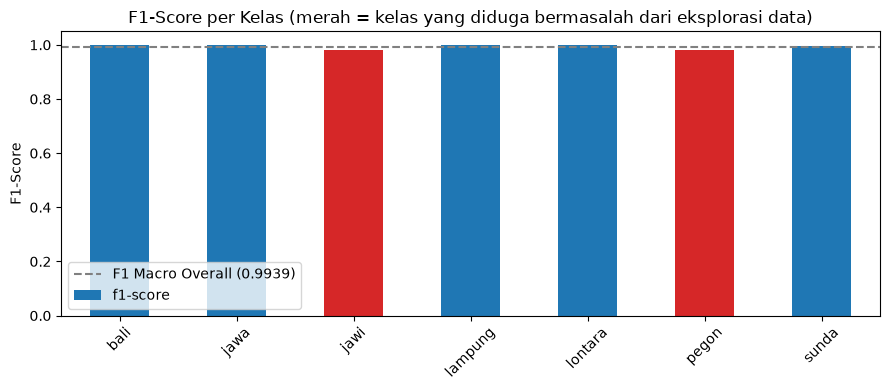

In [6]:
plt.figure(figsize=(9, 4))
f1_per_class = report_df.loc[classes_sorted, "f1-score"]
colors = ['tab:red' if c in ['jawi', 'pegon'] else 'tab:blue' for c in classes_sorted]
f1_per_class.plot(kind='bar', color=colors)
plt.title("F1-Score per Kelas (merah = kelas yang diduga bermasalah dari eksplorasi data)")
plt.ylabel("F1-Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.axhline(overall_f1, color='gray', linestyle='--', label=f'F1 Macro Overall ({overall_f1:.4f})')
plt.legend()
plt.tight_layout()
plt.show()


> **Catatan interpretasi (isi manual setelah lihat hasil):**
> - Apakah F1 kelas `jawi` dan `pegon` memang lebih rendah dibanding kelas lain, sesuai dugaan?
> - Atau ternyata tetap tinggi — berarti model cukup robust terhadap noise minor yang ditemukan,
>   ATAU val split kebetulan tidak kebagian sampel noise tersebut (cek di Section 5)?
> - Kelas mana yang F1-nya paling rendah secara keseluruhan?

## 4. Confusion Matrix

Melihat pola kesalahan: kelas mana yang paling sering tertukar dengan kelas lain. Berdasarkan
kemiripan visual (basis aksara Arab), dugaan awal adalah `jawi` dan `pegon` saling tertukar.

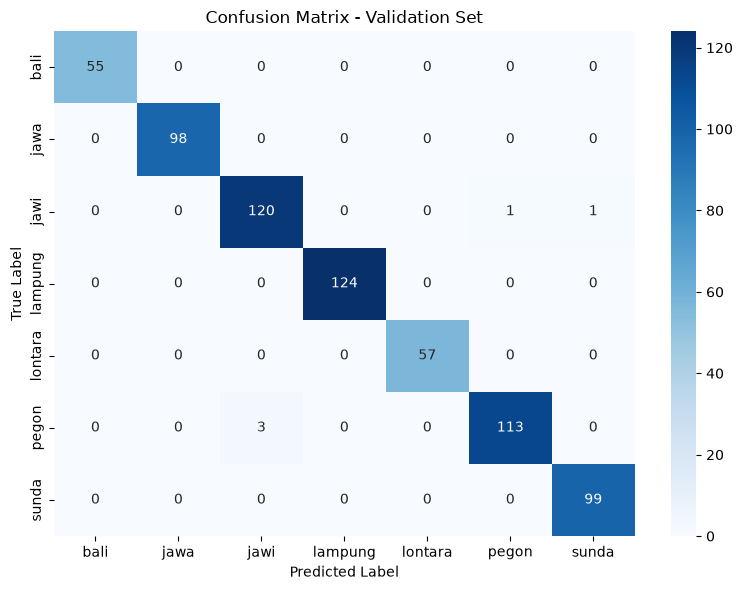

In [7]:
cm = confusion_matrix(val_labels, val_preds)
cm_df = pd.DataFrame(cm, index=classes_sorted, columns=classes_sorted)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title("Confusion Matrix - Validation Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


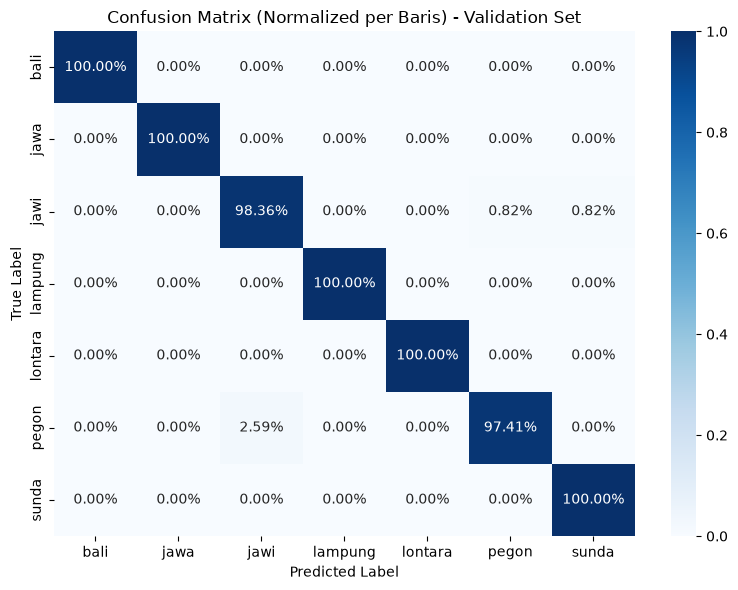

In [8]:
# Normalisasi per baris (recall view) — lebih mudah lihat proporsi kesalahan per kelas asli
cm_normalized = cm_df.div(cm_df.sum(axis=1), axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=True)
plt.title("Confusion Matrix (Normalized per Baris) - Validation Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


In [10]:
# Ekstrak pasangan kelas yang paling sering tertukar (off-diagonal terbesar)
cm_off_diag = cm_df.copy()
arr = cm_off_diag.to_numpy(copy=True)  # paksa buat array baru yang writable
np.fill_diagonal(arr, 0)
cm_off_diag = pd.DataFrame(arr, index=cm_off_diag.index, columns=cm_off_diag.columns)

confusion_pairs = []
for true_cls in classes_sorted:
    for pred_cls in classes_sorted:
        if true_cls != pred_cls and cm_off_diag.loc[true_cls, pred_cls] > 0:
            confusion_pairs.append((true_cls, pred_cls, cm_off_diag.loc[true_cls, pred_cls]))

confusion_pairs_df = pd.DataFrame(confusion_pairs, columns=["true_label", "predicted_as", "count"])
confusion_pairs_df = confusion_pairs_df.sort_values("count", ascending=False)
confusion_pairs_df


,true_label,predicted_as,count
2,pegon,jawi,3
0,jawi,pegon,1
1,jawi,sunda,1


> **Catatan interpretasi (isi manual):**
> - Pasangan kelas mana yang paling sering tertukar? Apakah sesuai dugaan (`jawi` <-> `pegon`)?
> - Apakah ada pasangan tertukar yang tidak terduga (misal kelas dengan bentuk visual jauh berbeda)?

## 5. Analisis Kelas Bermasalah (Jawi & Pegon)

Fokus khusus untuk mengecek dampak temuan sebelumnya: apakah sampel noise/mislabel di `jawi`
(gambar teks Latin "ng", "DAFTAR") kebetulan masuk ke validation set, dan bagaimana model
memprediksinya.

In [11]:
# Tampilkan semua sampel jawi & pegon di val set beserta prediksinya
jawi_pegon_results = results_df[results_df["true_label"].isin(["jawi", "pegon"])].sort_values(
    ["true_label", "is_correct"]
)
print(f"Total sampel jawi+pegon di val set: {len(jawi_pegon_results)}")
print(f"Salah prediksi: {(~jawi_pegon_results['is_correct']).sum()}")
jawi_pegon_results


Total sampel jawi+pegon di val set: 238
Salah prediksi: 5


,image_id,true_label,pred_label,confidence,is_correct
470,GcD27gkW.png,jawi,pegon,0.951692,False
493,20hRD1Xv.png,jawi,sunda,0.599977,False
0,rHHgzn2v.png,jawi,jawi,0.999776,True
22,JUggMaiq.png,jawi,jawi,0.989723,True
33,hPFhFSzp.png,jawi,jawi,0.999917,True
...,...,...,...,...,...
642,yIBh3dED.png,pegon,pegon,0.998786,True
653,wah3l5NK.png,pegon,pegon,0.999917,True
655,gDQk9Rbl.png,pegon,pegon,0.999651,True
662,GFzt5TQ1.png,pegon,pegon,0.999940,True


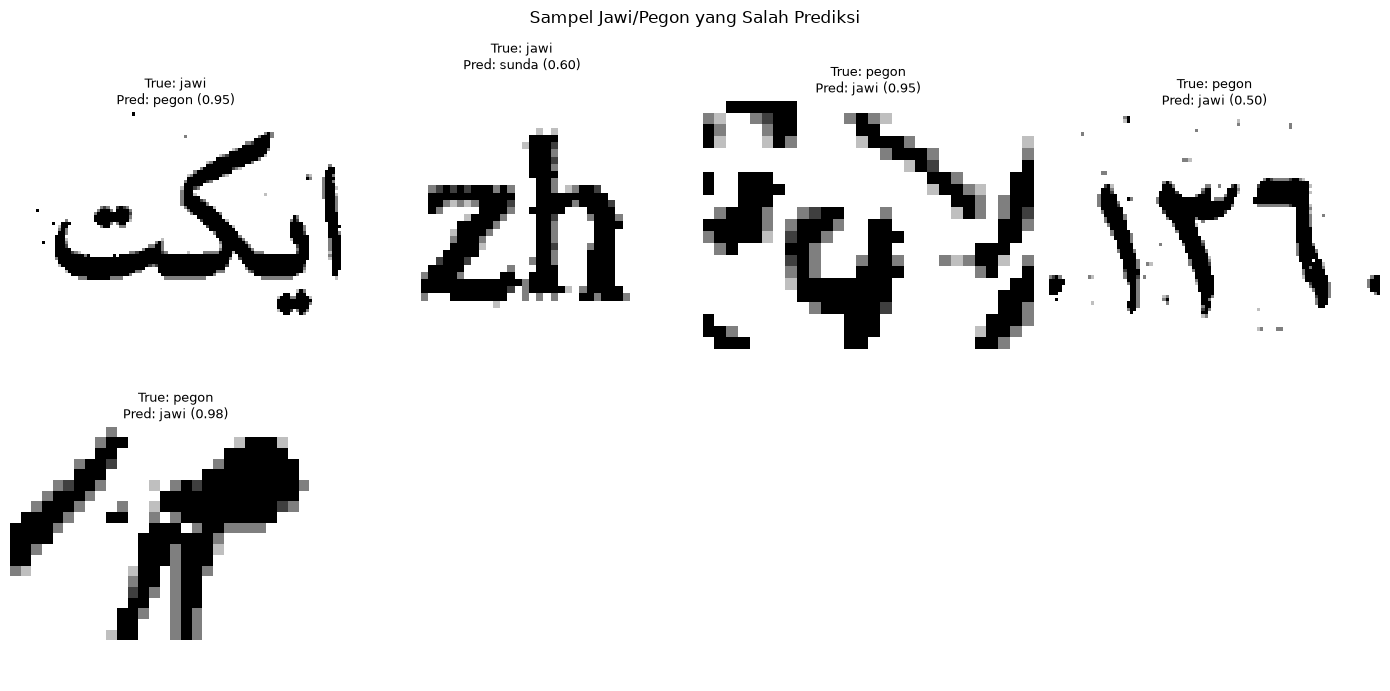

In [12]:
# Visualisasi sampel jawi/pegon yang SALAH prediksi (kalau ada)
wrong_jawi_pegon = jawi_pegon_results[~jawi_pegon_results["is_correct"]]

if len(wrong_jawi_pegon) > 0:
    n_show = min(len(wrong_jawi_pegon), 8)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, wrong_jawi_pegon.head(n_show).iterrows()):
        img_path = os.path.join(TRAIN_IMG_DIR, row["image_id"])
        img = Image.open(img_path)
        ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
        ax.set_title(f"True: {row['true_label']}\nPred: {row['pred_label']} ({row['confidence']:.2f})", fontsize=9)
        ax.axis('off')

    for ax in axes[n_show:]:
        ax.axis('off')

    plt.suptitle("Sampel Jawi/Pegon yang Salah Prediksi")
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada sampel jawi/pegon yang salah prediksi di validation set ini.")


> **Catatan interpretasi (isi manual):**
> - Apakah sampel yang ditemukan mislabel di eksplorasi awal (image_id spesifik dengan teks "ng"
>   atau "DAFTAR") kebetulan ada di val set? Kalau ada, apakah model salah prediksi (wajar karena
>   labelnya sendiri meragukan) atau tetap benar (model "menghafal" noise-nya)?
> - Kalau sampel noise itu ternyata ada di TRAIN set (bukan val), pertimbangkan investigasi lebih
>   lanjut: apakah perlu dibersihkan sebelum training ulang, supaya model tidak belajar dari label
>   yang salah?

## 6. Analisis Error: Sampel yang Salah Prediksi (Keseluruhan)

Melihat semua sampel yang salah prediksi di validation set (tidak dibatasi jawi/pegon saja),
untuk menangkap pola error lain yang mungkin terlewat.

In [13]:
all_wrong = results_df[~results_df["is_correct"]].sort_values("confidence", ascending=False)
print(f"Total salah prediksi: {len(all_wrong)} dari {len(results_df)} ({len(all_wrong)/len(results_df)*100:.2f}%)")
all_wrong


Total salah prediksi: 5 dari 671 (0.75%)


,image_id,true_label,pred_label,confidence,is_correct
625,vBAVAQ3Y.png,pegon,jawi,0.976367,False
470,GcD27gkW.png,jawi,pegon,0.951692,False
214,jMqPfFaa.png,pegon,jawi,0.945198,False
493,20hRD1Xv.png,jawi,sunda,0.599977,False
313,pYSqyrTl.png,pegon,jawi,0.501290,False


Salah prediksi dengan confidence > 0.8: 3


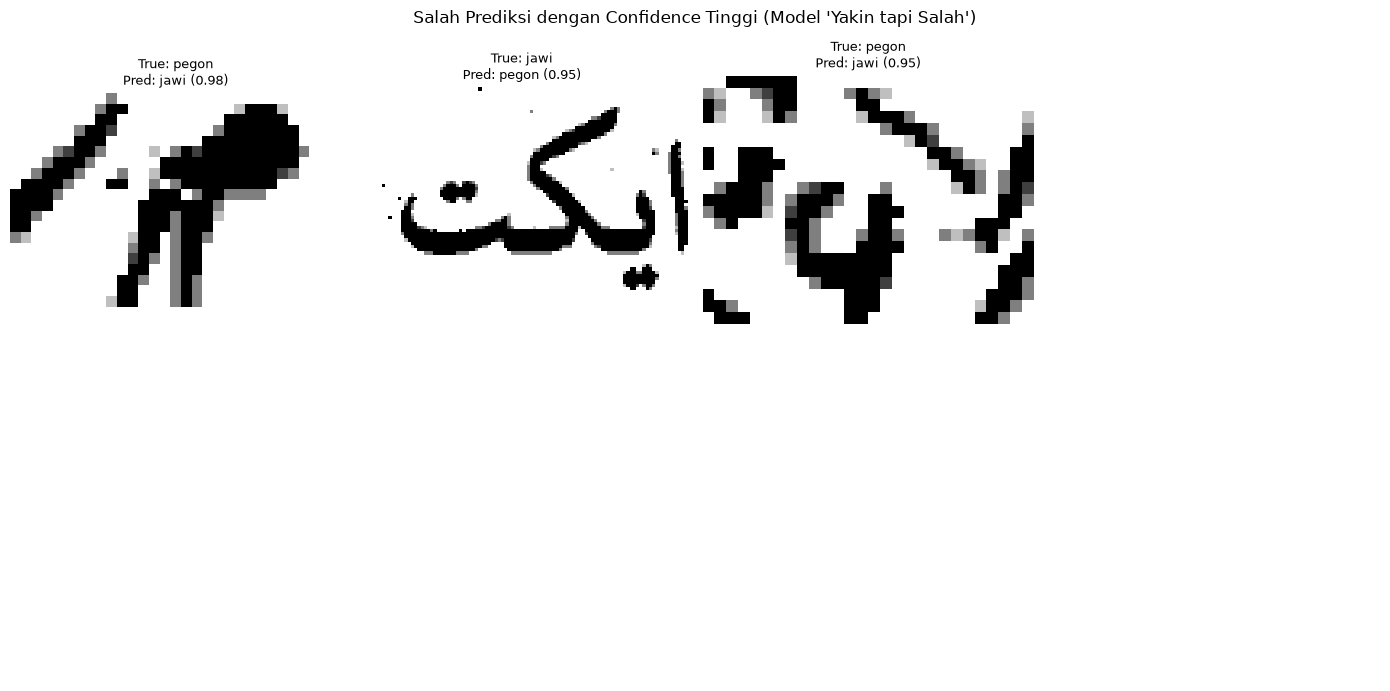

In [14]:
# Sampel salah prediksi dengan CONFIDENCE TINGGI paling menarik untuk dianalisis
# (model sangat yakin tapi salah -> kemungkinan besar kasus ambigu/mislabel, bukan sekadar model lemah)
high_conf_wrong = all_wrong[all_wrong["confidence"] > 0.8]
print(f"Salah prediksi dengan confidence > 0.8: {len(high_conf_wrong)}")

if len(high_conf_wrong) > 0:
    n_show = min(len(high_conf_wrong), 8)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, high_conf_wrong.head(n_show).iterrows()):
        img_path = os.path.join(TRAIN_IMG_DIR, row["image_id"])
        img = Image.open(img_path)
        ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
        ax.set_title(f"True: {row['true_label']}\nPred: {row['pred_label']} ({row['confidence']:.2f})", fontsize=9)
        ax.axis('off')

    for ax in axes[n_show:]:
        ax.axis('off')

    plt.suptitle("Salah Prediksi dengan Confidence Tinggi (Model 'Yakin tapi Salah')")
    plt.tight_layout()
    plt.show()


> **Catatan interpretasi (isi manual):**
> - Untuk kasus salah prediksi dengan confidence tinggi: apakah gambar tersebut memang ambigu
>   secara visual, atau kemungkinan mislabel di ground truth-nya?
> - Apakah ada pola tertentu pada error (misal semua error terjadi pada gambar dengan noise berat,
>   atau pada gambar dengan aspect ratio ekstrem)?

## 7. Kesimpulan & Rekomendasi

**Ringkasan hasil evaluasi (isi manual berdasarkan temuan di atas):**

- **F1 Macro overall:** ...
- **Kelas dengan F1 terendah:** ...
- **Pasangan kelas yang paling sering tertukar:** ...
- **Dampak noise/mislabel di `jawi`:** ...
- **Pola error lain yang ditemukan:** ...

**Rekomendasi untuk iterasi berikutnya (percobaan-2, dst):**
1. ...
2. ...
3. ...

**Untuk babak final (notebook/slide presentasi):**
- Confusion matrix dan per-class F1 di notebook ini bisa langsung dipakai sebagai bahan
  "Hasil dan Analisis" (bobot 25%) dan "Metodologi - penanganan ketidakseimbangan data" (bobot 25%)
  di babak final
- Temuan soal mislabel di `jawi` bisa jadi bahan diskusi menarik saat sesi tanya jawab juri —
  menunjukkan pemahaman mendalam terhadap dataset (bukan cuma jalankan model)

**Lanjut ke:** `04_final_submission.ipynb` — generate prediksi untuk `test.csv` dan `submission.csv`
sesuai format lomba.